<a href="https://colab.research.google.com/github/Elijah-Mumo/XAI_ELIAS_DS_R_Projects-crispy_waffle/blob/main/Financial_Inclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
# Important packages for data manipulation, numerical operations, plotting, and warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
np.random.seed(123) # Set numpy random seed for reproducibility
warnings.filterwarnings('ignore') # Filter out warnings for cleaner output
%matplotlib inline
# Enable inline plotting for matplotlib in Jupyter/Colab

In [73]:
# Import train and test datasets from CSV files
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

# Print the shape of the train and test dataframes
print('train data shape :', train.shape)
print('test data shape :', test.shape)

# Display the first few rows of the training dataframe
print(train.head())

# Display concise summary of the DataFrame
print(train.info())

train data shape : (23524, 13)
test data shape : (10086, 12)
  country  year    uniqueid bank_account location_type cellphone_access  \
0   Kenya  2018  uniqueid_1          Yes         Rural              Yes   
1   Kenya  2018  uniqueid_2           No         Rural               No   
2   Kenya  2018  uniqueid_3          Yes         Urban              Yes   
3   Kenya  2018  uniqueid_4           No         Rural              Yes   
4   Kenya  2018  uniqueid_5           No         Urban               No   

   household_size  age_of_respondent gender_of_respondent  \
0               3                 24               Female   
1               5                 70               Female   
2               5                 26                 Male   
3               5                 34               Female   
4               8                 26                 Male   

  relationship_with_head           marital_status  \
0                 Spouse  Married/Living together   
1      Head of 

In [74]:
from sklearn.model_selection import train_test_split

# Drop 'uniqueid' from training features; store test 'uniqueid' for later
X_train_processed_df = X_train.drop(['uniqueid'], axis=1)
test_ids = test['uniqueid']
test_processed_df = test.drop(['uniqueid'], axis=1)

# Fit and transform features; output is dense numpy array
processed_train_array = preprocessor.fit_transform(X_train_processed_df)
processed_test_array = preprocessor.transform(test_processed_df)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Convert processed arrays back to DataFrames
processed_train = pd.DataFrame(processed_train_array, columns=all_feature_names)
processed_test = pd.DataFrame(processed_test_array, columns=all_feature_names)

# Display processed training data sample and shape
print('Processed Train Data Sample (first row):')
print(processed_train.head(1))
print('Shape of Processed Train Data:', processed_train.shape)

# Split processed training data into training and validation sets, stratified by target
X_Train, X_Val, y_Train, y_val = train_test_split(processed_train, y_train, stratify=y_train,
                                                  test_size=0.1, random_state=42)

Processed Train Data Sample (first row):
   household_size  age_of_respondent  year  country_Kenya  country_Rwanda  \
0             0.1           0.095238   1.0            1.0             0.0   

   country_Tanzania  country_Uganda  location_type_Rural  location_type_Urban  \
0               0.0             0.0                  1.0                  0.0   

   cellphone_access_No  ...  job_type_Dont Know/Refuse to answer  \
0                  0.0  ...                                  0.0   

   job_type_Farming and Fishing  job_type_Formally employed Government  \
0                           0.0                                    0.0   

   job_type_Formally employed Private  job_type_Government Dependent  \
0                                 0.0                            0.0   

   job_type_Informally employed  job_type_No Income  job_type_Other Income  \
0                           0.0                 0.0                    0.0   

   job_type_Remittance Dependent  job_type_Self emplo

In [75]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Convert the 'bank_account' target column from categorical ('Yes'/'No') to numerical (1/0)
le = LabelEncoder()
train['bank_account'] = le.fit_transform(train['bank_account'])

# Separate features (X_train) from the target variable (y_train)
X_train = train.drop(['bank_account'], axis=1)
y_train = train['bank_account']

print(y_train)

# Define numerical and categorical feature names for preprocessing
numerical_features = ["household_size", "age_of_respondent", "year"]
categorical_features = [
    "country",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features), # Apply MinMaxScaler to numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Apply OneHotEncoder to categorical features
    ],
    remainder='drop' # Drop any unspecified columns
)

0        1
1        0
2        1
3        0
4        0
        ..
23519    0
23520    0
23521    0
23522    0
23523    0
Name: bank_account, Length: 23524, dtype: int64


In [76]:
from sklearn.model_selection import train_test_split

# Drop 'uniqueid' from training features as it's not used in model training
X_train_processed_df = X_train.drop(['uniqueid'], axis=1)
# Store 'uniqueid' from the test set for later submission
test_ids = test['uniqueid']
# Drop 'uniqueid' from test features for preprocessing
test_processed_df = test.drop(['uniqueid'], axis=1)

# Fit the preprocessor on the training features and transform both training and test features
# The preprocessor returns dense numpy arrays when sparse_output=False, so .toarray() is not needed.
processed_train_array = preprocessor.fit_transform(X_train_processed_df)
processed_test_array = preprocessor.transform(test_processed_df)

# Get the names of the features after one-hot encoding for the categorical columns
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# Combine numerical feature names with the new categorical feature names
all_feature_names = numerical_features + list(cat_feature_names)

# Convert the processed numpy arrays back to pandas DataFrames, assigning the correct column names
processed_train = pd.DataFrame(processed_train_array, columns=all_feature_names)
processed_test = pd.DataFrame(processed_test_array, columns=all_feature_names)

# Display the first row of the processed training data and its shape for verification
print('Processed Train Data Sample (first row):')
print(processed_train.head(1))
print('Shape of Processed Train Data:', processed_train.shape)

# Split the processed training data into training and validation sets
# stratify=y_train ensures that the proportion of target variable classes is maintained in both sets
# test_size=0.1 means 10% of the data will be used for validation
# random_state for reproducibility
X_Train, X_Val, y_Train, y_val = train_test_split(processed_train, y_train, stratify=y_train,
                                                  test_size=0.1, random_state=42)

Processed Train Data Sample (first row):
   household_size  age_of_respondent  year  country_Kenya  country_Rwanda  \
0             0.1           0.095238   1.0            1.0             0.0   

   country_Tanzania  country_Uganda  location_type_Rural  location_type_Urban  \
0               0.0             0.0                  1.0                  0.0   

   cellphone_access_No  ...  job_type_Dont Know/Refuse to answer  \
0                  0.0  ...                                  0.0   

   job_type_Farming and Fishing  job_type_Formally employed Government  \
0                           0.0                                    0.0   

   job_type_Formally employed Private  job_type_Government Dependent  \
0                                 0.0                            0.0   

   job_type_Informally employed  job_type_No Income  job_type_Other Income  \
0                           0.0                 0.0                    0.0   

   job_type_Remittance Dependent  job_type_Self emplo

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier


# Initialize classifier models
lg_model = LogisticRegression()
rf_model = RandomForestClassifier()
kn_model = KNeighborsClassifier()
et_model = ExtraTreesClassifier()
# xg_model removed to avoid conflicts with optimized xgb_model

# Fit models to training data
lg_model.fit(X_Train,y_Train)
rf_model.fit(X_Train,y_Train)
kn_model.fit(X_Train,y_Train)
et_model.fit(X_Train,y_Train)
# xg_model fitting removed

ExtraTreesClassifier()

In [78]:
# import evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score

# evaluate the model
lg_y_pred = lg_model.predict(X_Val)
rf_y_pred = rf_model.predict(X_Val)
kn_y_model = kn_model.predict(X_Val)
et_y_model = et_model.predict(X_Val)
# Corrected variable name from xg_model to xgb_model
xg_y_model = xgb_model.predict(X_Val)

# Get error rate
print("Error rate Logistic Regression classifier: ", 1 - accuracy_score(y_val, lg_y_pred))
print("Error rate of Random Forest classifier: ", 1 - accuracy_score(y_val, rf_y_pred))
print("Error rate of K Neighbors classifier: ", 1 - accuracy_score(y_val, kn_y_model))
print("Error rate of Extra Tree classifier: ", 1 - accuracy_score(y_val, et_y_model))
print("Error rate of XGB classifier: ", 1 - accuracy_score(y_val, xg_y_model))

Error rate Logistic Regression classifier:  0.11219719507012327
Error rate of Random Forest classifier:  0.13769655758606036
Error rate of K Neighbors classifier:  0.12154696132596687
Error rate of Extra Tree classifier:  0.15129621759456013
Error rate of XGB classifier:  0.10667233319167024


In [79]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions on the validation set for each trained model
lg_y_pred = lg_model.predict(X_Val)
rf_y_pred = rf_model.predict(X_Val)
kn_y_model = kn_model.predict(X_Val)
et_y_model = et_model.predict(X_Val)
# Assuming xgb_model refers to the best model from the next cell
xg_y_model = xgb_model.predict(X_Val)

# Calculate and print the error rate (1 - accuracy) for each classifier
print("Error rate Logistic Regression classifier: ", 1 - accuracy_score(y_val, lg_y_pred))
print("Error rate of Random Forest classifier: ", 1 - accuracy_score(y_val, rf_y_pred))
print("Error rate of K Neighbors classifier: ", 1 - accuracy_score(y_val, kn_y_model))
print("Error rate of Extra Tree classifier: ", 1 - accuracy_score(y_val, et_y_model))
print("Error rate of XGB classifier: ", 1 - accuracy_score(y_val, xg_y_model))

Error rate Logistic Regression classifier:  0.11219719507012327
Error rate of Random Forest classifier:  0.13769655758606036
Error rate of K Neighbors classifier:  0.12154696132596687
Error rate of Extra Tree classifier:  0.15129621759456013
Error rate of XGB classifier:  0.10667233319167024


Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 1.0}
xgb_model (best_estimator_) reports 40 features.
X_Val has 40 features.
Error rate of the XGB classifier:  0.10667233319167024


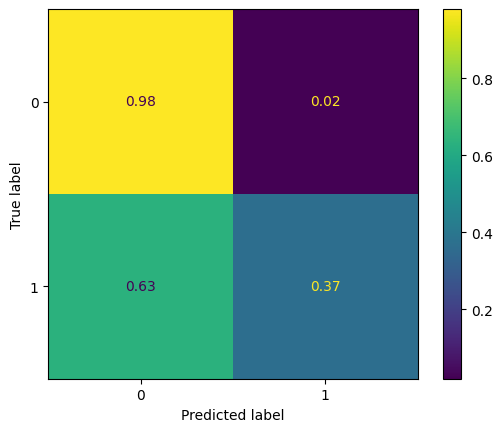

                      uniqueid  bank_account
415      uniqueid_6484 x Kenya             0
5296   uniqueid_11431 x Rwanda             0
6820  uniqueid_7095 x Tanzania             0
4300   uniqueid_10435 x Rwanda             0
8934  uniqueid_9209 x Tanzania             0


In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Define parameter grid for GridSearchCV to optimize XGBoost hyperparameters
param_grid = {'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1],
        'subsample': [0.6, 0.8, 1.0],
        'max_depth': [3, 5]}

# Initialize base XGBClassifier for GridSearchCV (disable categorical, set random state)
xgb_base = XGBClassifier(objective='binary:logistic', eval_metric='logloss', enable_categorical=False, random_state=42)
# Initialize GridSearchCV to find best hyperparameters
my_xgb_model = GridSearchCV(xgb_base, param_grid,n_jobs=-1,verbose=2,cv=5)
# Fit GridSearchCV on training data
my_xgb_model.fit(X_Train, y_Train)
print(my_xgb_model.best_params_)

from sklearn.metrics import confusion_matrix, accuracy_score

# Assign the best estimator from GridSearchCV to xgb_model
xgb_model = my_xgb_model.best_estimator_

# Print feature counts for debugging
print(f"xgb_model (best_estimator_) reports {xgb_model.n_features_in_} features.")
print(f"X_Val has {X_Val.shape[1]} features.")

# Make predictions on the validation set
y_pred = xgb_model.predict(X_Val)

# Calculate and print error rate
print("Error rate of the XGB classifier: ", 1 - accuracy_score(y_val, y_pred))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(xgb_model,X_Val,y_val,normalize='true')
plt.show()

# Make predictions on test data
test['bank_account'] = xgb_model.predict(processed_test)

# Create submission DataFrame
submission = pd.DataFrame({"uniqueid": test["uniqueid"] + " x " + test["country"],
                           "bank_account": test['bank_account']})

# Display sample of submission DataFrame
print(submission.sample(5))

# Save submission to CSV
submission.to_csv('ElijahM_uno_submission.csv', index = False)

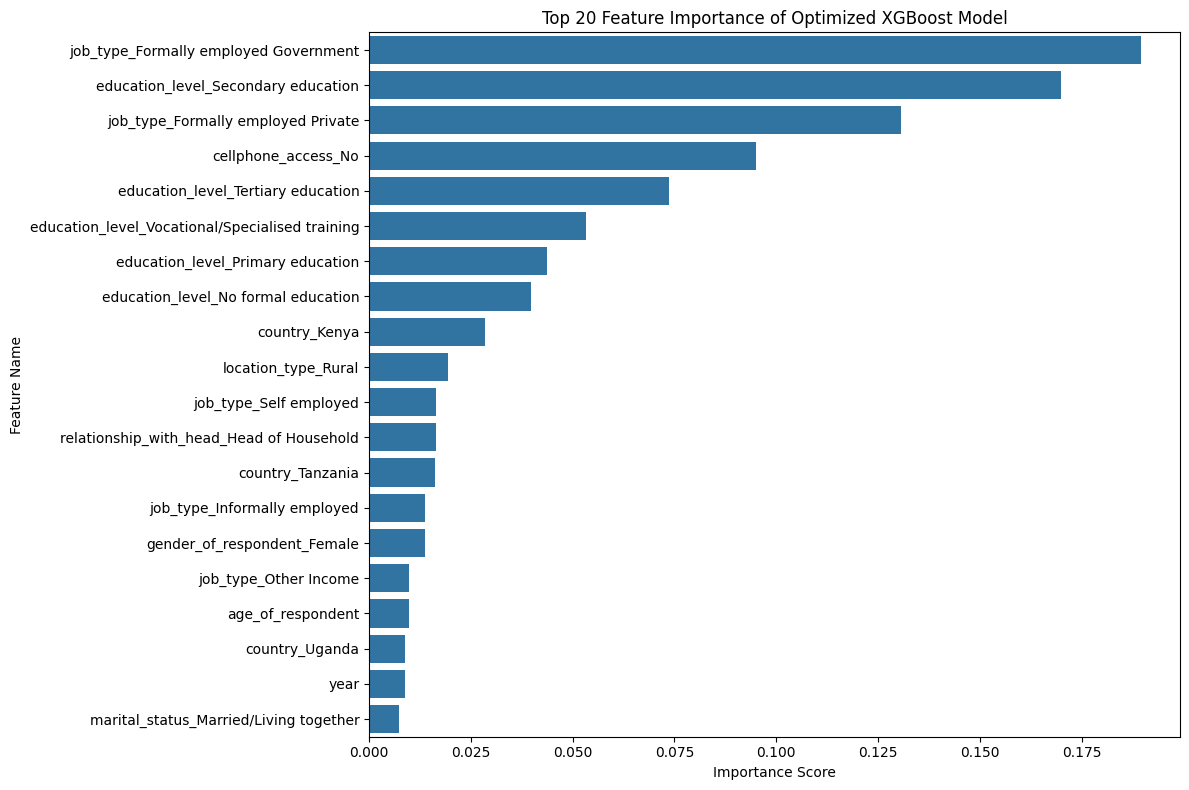

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the optimized XGBoost model
feature_importances = xgb_model.feature_importances_
# Get feature names from training data columns
feature_names = X_Train.columns.tolist()

# Combine feature names and importances
data = list(zip(feature_names, feature_importances))

# Create DataFrame for importances
importance_df = pd.DataFrame(data, columns=['Feature', 'Importance'])

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top N feature importances
n_features = 20 # Number of top features to display
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(n_features))
plt.title(f'Top {n_features} Feature Importance of Optimized XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

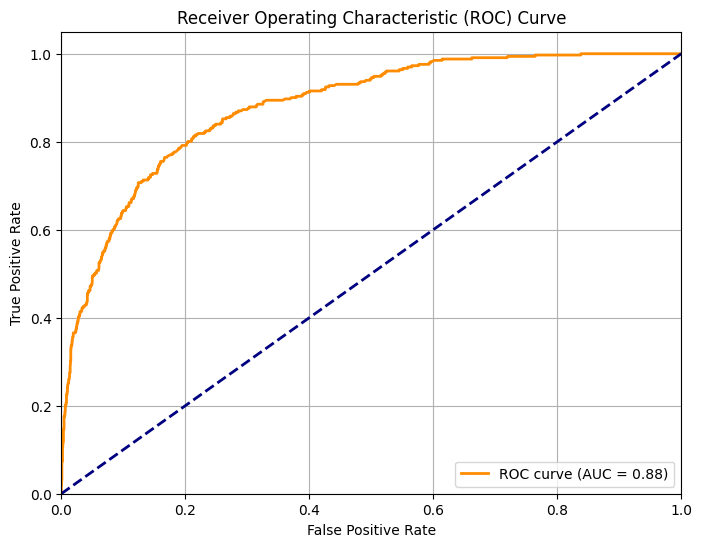

In [82]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Retrieve best parameters from GridSearchCV result
best_params = my_xgb_model.best_params_

# Create new XGBClassifier instance with best parameters and disabled categorical features
roc_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    enable_categorical=False,
    random_state=42,
    **best_params
)

# Fit new model on training data
roc_xgb_model.fit(X_Train, y_Train)

# Get predicted probabilities for positive class on validation set
y_pred_proba = roc_xgb_model.predict_proba(X_Val)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()